<a href="https://colab.research.google.com/github/JKniaaa/SC3000-Artificial-Intelligence/blob/dev/Lab%201/cartpole.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Balancing a Pole on a Cart

## 24S2 SC3000 Assignment 1

---

by **Goh Jun Keat**

Github Repository: [SC3000 - Artificial Intelligence](https://github.com/JKniaaa/SC3000-Artificial-Intelligence)

---

## Project Description

A pole is attached by an un-actuated joint to a cart, which moves along a frictionless track. The pendulum is placed upright on the cart, and the goal is to balance the pole by applying forces in the left and right directions on the cart. In this project, I will develop a **Reinforcement Learning (RL) agent**. The trained agent makes the decision to push the cart to the left or right based on the cart position, velocity, pole angle, and angular velocity.

---

### Action Space

The action space is an `ndarray` with shape `(1,)`, which can take values `{0, 1}` indicating pushing the cart to the left or right, respectively. Note that the velocity that is reduced or increased by the applied force is not fixed and depends on the angle the pole is pointing. The center of gravity of the pole varies the amount of energy needed to move the cart underneath it.

---

### Observation Space

The observation space is an `ndarray` with shape `(4,)` consisting of the following positions and velocities:

| Num | Observation             | Min                  | Max                  |
|-----|-------------------------|----------------------|----------------------|
| 0   | Cart Position           | -4.8                 | 4.8                  |
| 1   | Cart Velocity           | -∞                   | ∞                    |
| 2   | Pole Angle              | ~ -0.418 rad (-24°)  | ~ 0.418 rad (24°)    |
| 3   | Pole Angular Velocity   | -∞                   | ∞                    |

---

### Rewards

- A reward of **+1** is given for every step taken, including the termination step.
- The goal is to keep the pole upright for as long as possible.

---

### Conditions

- All observations are assigned a uniformly random value in the range `(-0.05, 0.05)`.
- Episodes are considered to end if:
  - The pole angle exceeds **±12°**.
  - The cart position exceeds **±2.4** (i.e., the center of the cart reaches the edge of the display).
  - The episode length exceeds **500** steps.

---


### Install Dependencies

Before running this notebook, you can alternatively install the required dependencies by running:

```bash
pip install -r requirements.txt

In [1]:
!pip install numpy==1.26.0
!pip install tensorflow==2.18.0
!pip install gym==0.25.2
!pip install ipython==7.34.0
!pip install matplotlib==3.10.0
!pip install opencv-python==4.11.0.86
!pip install ipykernel==6.17.1
!pip install pygame==2.6.1
!pip install imageio-ffmpeg==0.6.0


[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Importing Dependencies and Defining Helper Function


In [2]:
import gym
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from gym.wrappers import RecordVideo
from IPython.display import HTML, display
import time
import os
import glob
import base64
import io
import cv2
import math

def show_video():
  mp4list = glob.glob('video/*.mp4')
  if len(mp4list) > 0:
    mp4 = mp4list[0]
    video = io.open(mp4, 'r+b').read()
    encoded = base64.b64encode(video)
    display(HTML(data='''<video alt="test" autoplay
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))
  else:
    print("Could not find video")

## Loading CartPole Environment

This line creates an instance of the **CartPole-v1** environment using the OpenAI Gym library.

In [3]:
env = gym.make("CartPole-v1")

c:\Users\junke\OneDrive\Desktop\SC3000-Artificial-Intelligence\.venv\Lib\site-packages\gym\core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
c:\Users\junke\OneDrive\Desktop\SC3000-Artificial-Intelligence\.venv\Lib\site-packages\gym\wrappers\step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


We can check the action and observation space of this environment. Discrete(2) means that there are two valid discrete actions: 0 & 1, for pushing the cart to the left or right.

In [4]:
print(env.action_space)

Discrete(2)


The observation space is given below. The first two arrays define the min and max values of the 4 observed values, corresponding to cart position, velocity and pole angle, angular velocity.

In [5]:
print(env.observation_space)

Box([-4.8000002e+00 -3.4028235e+38 -4.1887903e-01 -3.4028235e+38], [4.8000002e+00 3.4028235e+38 4.1887903e-01 3.4028235e+38], (4,), float32)


We call each round of the pole-balancing game an "episode". At the start of each episode, make sure the environment is reset, which chooses a random initial state, e.g., pole slightly tilted to the right. This initialization can be achieved by the code below, which returns the observation of the initial state.

In [6]:
observation = env.reset()
print("Initial observations: ", observation)

Initial observations:  [-0.00820913  0.04237678  0.03430782 -0.03879282]


For the CartPole environment, there are two possible actions: 0 for pushing to the left and 1 for pushing to the right. For example, we can push the cart to the left using code below, which returns the new observation, the current reward, an indicator of whether the game ends, and some additional information (not used in this project). For CartPole, the game ends when the pole is significantly tilted or you manage to balance the pole for 500 steps. You get exactly 1 reward for each step before the game ends (i.e., max cumulative reward is 500).

In [7]:
observation, reward, done, info = env.step(0)
print("New observations after choosing action 0:", observation)
print("Reward for this step:", reward)
print("Is this round done?", done)
print("Additional info:", info)

New observations after choosing action 0: [-0.00736159 -0.15321992  0.03353197  0.2645141 ]
Reward for this step: 1.0
Is this round done? False
Additional info: {}


c:\Users\junke\OneDrive\Desktop\SC3000-Artificial-Intelligence\.venv\Lib\site-packages\gym\utils\passive_env_checker.py:241: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Now we can play a full round of the game using a naive strategy (always choosing action 0), and show the cumulative reward in the round. Note that reward returned by env.step(*) corresponds to the reward for current step. So we have to accumulate the reward for each step. Clearly, the naive strategy performs poorly by surviving only a dozen of steps.

In [8]:
observation = env.reset()
cumulative_reward = 0
done = False
while not done:
    observation, reward, done, info = env.step(0)
    cumulative_reward += reward
print("Cumulative reward for this round:", cumulative_reward)

Cumulative reward for this round: 10.0


## RL Agent with Q-Learning Algorithm

For this project, the **Reinforcement Learning (RL)** agent I am implementing will use the **Q-Learning** algorithm to solve the **CartPole-v1** environment. The agent learns by interacting with the environment and updating its knowledge based on the rewards it receives.

### Q-Learning Algorithm
Q-learning is a **model-free reinforcement learning** algorithm. It helps the agent learn the optimal action-selection policy by updating a **Q-matrix** that stores expected rewards for state-action pairs. The agent selects actions based on the Q-values and learns over time by improving its policy.

The key update rule in Q-learning is:

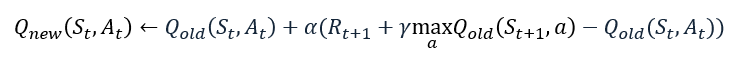

**Where**:
- **Q(s, a)**: Current Q-value for state \( s \) and action \( a \).
- **α** (alpha): Learning rate (0 < α ≤ 1)
- **R(s, a)**: Immediate reward received after taking action \( a \) in state \( s \).
- **γ** (gamma): Discount factor (0 ≤ γ < 1)
- **maxₐ′ Q(s′, a′)**: Maximum estimated future reward for the next state \( s' \).

## Training the RL Agent

Firstly, the **CardPole-v1** environment is reset and reinitialised, then some initial values and parameters and set up for the **Q-Learning** algorithm.

Parameters ***'alpha'***, ***'gamma'*** and ***'epsilon'*** represent the learning rate, discount factor and exploration rate respectively.

Variables ***'numBinsPosition'***, ***'numBinsVelocity'***, ***'numBinsPoleAngle'*** and ***'numBinsPoleAngleVelocity'*** determine the number of bins to discretize the observation space for the `Q-matrix`.

Variable ***'numAction'*** is the number of possible actions in the given environment.

Variable ***'Q-matrix'*** is initialised uniformly as a numpy array with random values between 0 and 1. The number of dimensions is equivalent to the number of bins in each dimension of the observation space and number of actions.

Variables ***'UpperBound'*** and ***'LowerBound'*** are arrays which define the maximum values and minimum values of each dimension of the observation space. The bounds for the `velocity` and `poleAngleVelocity` are adjusted to the values defined for the project.

In [9]:
env = gym.make("CartPole-v1")

# initialise values
alpha = 0.1
gamma = 1
epsilon = 0.2  # agent explores 20% of the time and chooses greedy action 80% of the time
numAction = env.action_space.n
numBinsPosition = 30
numBinsVelocity = 30
numBinsPoleAngle = 30
numBinsPoleAngleVelocity = 30
numBins = [numBinsPosition, numBinsVelocity, numBinsPoleAngle, numBinsPoleAngleVelocity]
sumRewardsEpisode = []

# initialise Q-matrix
Qmatrix = np.random.uniform(low=0, high=1, size=(numBins[0], numBins[1], numBins[2], numBins[3], numAction))

# set boundaries
upperBounds = env.observation_space.high
lowerBounds = env.observation_space.low
maxVelocity = 3
minVelocity = -3
maxPoleAngleVelocity = 10
minPoleAngleVelocity = -10
upperBounds[1], lowerBounds[1] = maxVelocity, minVelocity
upperBounds[3], lowerBounds[3] = maxPoleAngleVelocity, minPoleAngleVelocity

Function ***'returnIndexState(state)'*** takes in a state vector and returns the closest bin index for each element in the state. The state consists of four components: `position`, `velocity`, `poleAngle`, and `poleAngleVelocity`. The function discretizes these values into bins and returns the corresponding indices.

The process is as follows:

1. The function first extracts the values of `position`, `velocity`, `poleAngle`, and `poleAngleVelocity` from the input `state`.
2. It creates bins for each of these variables using `np.linspace()` to create equally spaced values between the lower and upper bounds.
3. The `np.digitize()` function is used to find the index of the closest bin for each variable in the state.
4. The function returns a **tuple of four values representing the indices of the closest bins** for `position`, `velocity`, `poleAngle`, and `poleAngleVelocity`.


In [10]:
def returnIndexState(state):

  # get current state values
  position = state[0]
  velocity = state[1]
  poleAngle = state[2]
  poleAngleVelocity = state[3]

  # create bins for each value of state
  positionBin = np.linspace(lowerBounds[0], upperBounds[0], numBins[0])
  velocityBin = np.linspace(lowerBounds[1], upperBounds[1], numBins[1])
  poleAngleBin = np.linspace(lowerBounds[2], upperBounds[2], numBins[2])
  poleAngleVelocityBin = np.linspace(lowerBounds[3], upperBounds[3], numBins[3])

  # return closest bin index to current state
  # need to -1 to ensure index start counting from 0
  positionIndex = np.maximum(np.digitize(position, positionBin) - 1, 0)
  velocityIndex = np.maximum(np.digitize(velocity, velocityBin) - 1, 0)
  poleAngleIndex = np.maximum(np.digitize(poleAngle, poleAngleBin) - 1, 0)
  poleAngleVelocityIndex = np.maximum(np.digitize(poleAngleVelocity, poleAngleVelocityBin) - 1, 0)

  return tuple([positionIndex, velocityIndex, poleAngleIndex, poleAngleVelocityIndex])

Function ***'selectAction(state, index, isTraining)'*** selects an action for the agent based on the current state, the episode index, and whether the agent is in training mode. The function uses an **epsilon-greedy strategy** for exploration and exploitation, with some adjustments based on the episode index.

The process is as follows:

1. **Exploration in First 500 Episodes**  
   If the current episode index is less than 500 and the agent **is in training mode**, the agent selects a random action to encourage exploration.

2. **Epsilon-Greedy Strategy**  
   - A random number is generated for the epsilon-greedy approach.
   - If the current episode index is greater than 7000, the epsilon value is reduced by 0.999 to promote exploitation.
   - If the **generated random number is less than the current epsilon value**, the agent explores by selecting a **random action.**
   - Otherwise, the agent exploits the learned values by selecting the **action with the highest Q-value from the `Qmatrix`** for the current state.

3. **Tie-breaking**  
   If there is a **tie** for the action with the highest Q-value, the function **randomly selects** one of the actions with the maximum Q-value.


In [11]:
def selectAction(state, index, isTraining):
  global epsilon

  # choose random actions for exploration in first 500 episodes
  if index < 500 and isTraining:
    return np.random.choice(numAction)

  # generate random number for epsilon greedy approach
  numRandom = np.random.random()

  # decrease epsilon value after 7000 episodes
  if index > 7000:
    epsilon = 0.999 * epsilon

  # if numRandom < epsilon, agent is exploring, select random actions
  if numRandom < epsilon:
    return np.random.choice(numAction)

  # else select action based on greedy approach
  # return index where Qmatrix[state] has max value
  else:
    # randomly selects action if there is a tie
    return np.random.choice(np.where(Qmatrix[returnIndexState(state)] == np.max(Qmatrix[returnIndexState(state)]))[0])


Function ***'simulateEpisodes(numEpisodes, isTraining)'*** simulates the training of an agent over a specified number of episodes. During each episode, the agent interacts with the environment by selecting actions based on its current state, updates its Q-values using the Q-learning algorithm, and accumulates rewards.

The process is as follows:

1. **Episode Loop**  
   The function loops over each episode from `0` to `numEpisodes - 1`. For each episode, the environment is reset, and the state is initialized.

2. **State and Action Selection**  
   In each episode, the agent interacts with the environment:
   - The current state (`stateS`) is indexed.
   - An action (`actionA`) is selected based on the current state using the `selectAction` function.
   - The environment returns the next state (`stateSprime`), the reward, and whether the state is terminal.
   
3. **Q-Learning Update**  
   If the state is not terminal:
   - The Q-value for the current state-action pair is updated based on the reward and the maximum Q-value of the next state.
   - The error is calculated as `reward + (gamma * QmaxPrime) - Qmatrix[stateSIndex + (actionA, )]`, and the Q-value is updated using the learning rate (`alpha`).
   
   If the state is terminal:
   - The Q-value for the current state-action pair is updated based on the reward alone (as the next state does not exist).
   - The error is calculated as `reward - Qmatrix[stateSIndex + (actionA, )]`.

4. **Reward Tracking**  
   The reward for each step in the episode is appended to `rewardsEpisode`, and the sum of the rewards for the episode is added to `sumRewardsEpisode`.

5. **Termination**  
   The loop terminates when the agent reaches a terminal state.

In [12]:
# To train the agent
def simulateEpisodes(numEpisodes, isTraining):
  # Reset the list
  global sumRewardsEpisode
  sumRewardsEpisode = []  

  for curEpisode in range(numEpisodes):

    # stateS = current state
    # actionA = current action
    # anything with "prime" => next state/action

    # store rewards per episode
    rewardsEpisode = []

    # reset environment
    stateS = env.reset()
    stateS = list(stateS)

    print("Simulating episode {}".format(curEpisode))

    # go from one state to another until terminal state
    terminalState = False
    while not terminalState:
      # return current state index
      stateSIndex = returnIndexState(stateS)

      # select action based on current state
      actionA = selectAction(stateS, curEpisode, isTraining)

      # determine whether next state is terminal state
      stateSprime, reward, terminalState, _ = env.step(actionA)
      rewardsEpisode.append(reward)
      stateSprime = list(stateSprime)
      stateSprimeIndex = returnIndexState(stateSprime)

      # return max value
      QmaxPrime = np.max(Qmatrix[stateSprimeIndex])

      if not terminalState:
        # (stateS + (actionA, )) used for appending tuples
        # let stateS = [0, 0, 0, 1], actionA = [1, 0]
        # stateS + (actionA, ) = [0, 0, 0, 1, 0]
        error = reward + (gamma * QmaxPrime) - Qmatrix[stateSIndex + (actionA, )]
        Qmatrix[stateSIndex + (actionA, )] = Qmatrix[stateSIndex + (actionA, )] + (alpha * error)

      else:
        # for terminal state, Qmatrix[stateSprime, actionAprime] = 0
        error = reward - Qmatrix[stateSIndex + (actionA, )]
        Qmatrix[stateSIndex + (actionA, )] = Qmatrix[stateSIndex + (actionA, )] + (alpha * error)

      # update current state
      stateS = stateSprime

    print("Sum of rewards {}".format(np.sum(rewardsEpisode)))
    sumRewardsEpisode.append(np.sum(rewardsEpisode))

Then, the RL Agent is trained with 30000 episodes.

In [13]:
# run 30000 episodes to train the agent
simulateEpisodes(30000, True)

Simulating episode 0
Sum of rewards 25.0
Simulating episode 1
Sum of rewards 17.0
Simulating episode 2
Sum of rewards 14.0
Simulating episode 3
Sum of rewards 15.0
Simulating episode 4
Sum of rewards 21.0
Simulating episode 5
Sum of rewards 58.0
Simulating episode 6
Sum of rewards 19.0
Simulating episode 7
Sum of rewards 12.0
Simulating episode 8
Sum of rewards 11.0
Simulating episode 9
Sum of rewards 15.0
Simulating episode 10
Sum of rewards 37.0
Simulating episode 11
Sum of rewards 16.0
Simulating episode 12
Sum of rewards 35.0
Simulating episode 13
Sum of rewards 17.0
Simulating episode 14
Sum of rewards 25.0
Simulating episode 15
Sum of rewards 12.0
Simulating episode 16
Sum of rewards 40.0
Simulating episode 17
Sum of rewards 13.0
Simulating episode 18
Sum of rewards 36.0
Simulating episode 19
Sum of rewards 29.0
Simulating episode 20
Sum of rewards 38.0
Simulating episode 21
Sum of rewards 20.0
Simulating episode 22
Sum of rewards 17.0
Simulating episode 23
Sum of rewards 36.0
Si

# Task 1: Development of an RL Agent

**`QLAgent`** is a developed agent that selects the best action based on the current observation using the learned Q-table.

In [14]:
def QLAgent(observation, Qmatrix):
    stateIndex = returnIndexState(list(observation))
    action = np.argmax(Qmatrix[stateIndex])

    return action

The correctness of the implementation can be demonstrated by sampling a random state from the cart pole environment, inputting to the agent, and outputting a chosen action. 

In [15]:
observation = env.reset()
action = QLAgent(observation, Qmatrix)
print("Observation:", observation)
print("Chosen action:", action)

Observation: [ 0.00076886  0.03808806  0.04926892 -0.0072855 ]
Chosen action: 1


# Task 2: Demonstrate the Effectiveness of the RL Agent

To test **`QLAgent`**, we run the agent for 100 episodes.

In [16]:
# test agent by running 100 episodes
simulateEpisodes(100, False)

Simulating episode 0
Sum of rewards 164.0
Simulating episode 1
Sum of rewards 213.0
Simulating episode 2
Sum of rewards 273.0
Simulating episode 3
Sum of rewards 174.0
Simulating episode 4
Sum of rewards 191.0
Simulating episode 5
Sum of rewards 243.0
Simulating episode 6
Sum of rewards 181.0
Simulating episode 7
Sum of rewards 167.0
Simulating episode 8
Sum of rewards 244.0
Simulating episode 9
Sum of rewards 199.0
Simulating episode 10
Sum of rewards 230.0
Simulating episode 11
Sum of rewards 173.0
Simulating episode 12
Sum of rewards 172.0
Simulating episode 13
Sum of rewards 164.0
Simulating episode 14
Sum of rewards 218.0
Simulating episode 15
Sum of rewards 230.0
Simulating episode 16
Sum of rewards 142.0
Simulating episode 17
Sum of rewards 232.0
Simulating episode 18
Sum of rewards 193.0
Simulating episode 19
Sum of rewards 242.0
Simulating episode 20
Sum of rewards 245.0
Simulating episode 21
Sum of rewards 179.0
Simulating episode 22
Sum of rewards 211.0
Simulating episode 23

Then, a graph of cumulative reward against all 100 episodes was plotted.

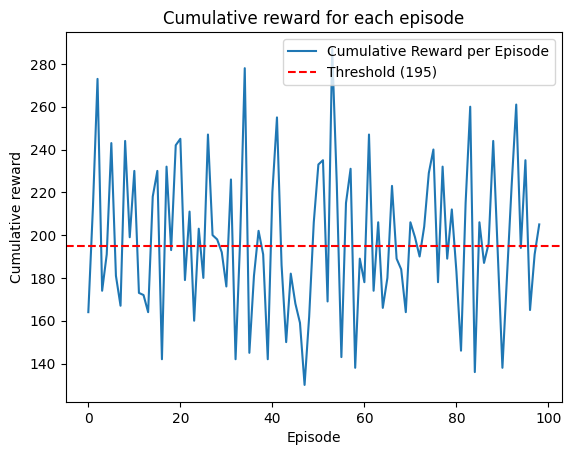

In [17]:
# Take results of 100 test episodes to evaluate the agent
testRewardsList = sumRewardsEpisode[-101:-1]
plt.plot(testRewardsList, label="Cumulative Reward per Episode")
plt.axhline(y=195, color='r', linestyle='--', label="Threshold (195)")
plt.title('Cumulative reward for each episode')
plt.ylabel('Cumulative reward')
plt.xlabel('Episode')
plt.legend()
plt.show()


The average reward across all the 100 episodes is also printed. The agent is considered good enough if the average reward is above 195.

In [18]:
avg = sum(testRewardsList) / len(testRewardsList)
print("Average cumulative reward:", avg)
print("Is my agent good enough?", avg > 195)

Average cumulative reward: 197.67676767676767
Is my agent good enough? True


Based on the analysis, **`QLAgent`** returns an average reward score of 197.68, which is higher that 195. The graph also shows that most of the episodes have a cumulative reward higher than 195.

Hence, it can be concluded that **`QLAgent`** is considered good enough and performs well.

# Task 3: Render 1 Episode Played by the Agent

I rendered 1 episode played by **`QLAgent`**. It looks like the developed RL Agent managed to balance the pole well for a decent amount of time. 

In [19]:
env = RecordVideo(gym.make("CartPole-v1"), "./video")
observation = env.reset()
while True:
    env.render()
    action = QLAgent(observation, Qmatrix)
    observation, reward, done, info = env.step(action)
    if done:
      break
env.close()
show_video()

c:\Users\junke\OneDrive\Desktop\SC3000-Artificial-Intelligence\.venv\Lib\site-packages\gym\wrappers\record_video.py:78: UserWarning: WARN: Overwriting existing videos at c:\Users\junke\OneDrive\Desktop\SC3000-Artificial-Intelligence\Assignment 1\video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
c:\Users\junke\OneDrive\Desktop\SC3000-Artificial-Intelligence\.venv\Lib\site-packages\gym\wrappers\monitoring\video_recorder.py:78: DeprecationWarning: WARN: Recording ability for environment CartPole-v1 initialized with `render_mode=None` is marked as deprecated and will be removed in the future.
  logger.deprecation(
c:\Users\junke\OneDrive\Desktop\SC3000-Artificial-Intelligence\.venv\Lib\site-packages\gym\core.py:43: DeprecationWarning: WARN: The argument mode in render method is deprecated; use render_mode during environment initialization instead.
See here for more information: https://www.gymlibrary.ml/content/api/

## Task 4: Format Jupyter Notebook

I have formatted the notebook as shown above by including step-by-step instructions and explanations, such that the notebook is easy to follow and run.

## References

- [Q-Learning in Python - GeeksforGeeks](https://www.geeksforgeeks.org/q-learning-in-python/)
- [Reinforcement Learning Tutorial - YouTube](https://www.youtube.com/watch?v=2sp_eucoX2I)
- [Q-Learning Tutorial in Python - Reinforcement Learning](https://www.youtube.com/watch?v=MSrfaI1gGjI)
- [CartPole with Q-Learning - YouTube](https://www.youtube.com/watch?v=TiAXhVAZQl8)
- Sample Codes from SC3000 Lab 1 Assignment Description
